In [ ]:
# %% [markdown]
# # Modelo Naïve Bayes para Mushroom Prediction
# Dataset: Mushroom - UCI Machine Learning Repository
# Objetivo: predecir si un hongo es comestible o venenoso

In [ ]:
# %% [markdown]
# ## 1. Cargar librerías y leer archivo

# Si no tienes instalada la librería, ejecuta esta línea una sola vez:
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score

from sklearn.inspection import permutation_importance

# Descargar dataset desde UCI
mushroom = fetch_ucirepo(id=73)

# Separar variables explicativas y objetivo
X = mushroom.data.features
y = mushroom.data.targets

# Unir X e y para revisar los datos
df = pd.concat([X, y], axis=1)

# Ver primeras filas
df.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


Filas y columnas: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


Distribución de la variable objetivo:
poisonous
e            4208
p            3916
Name: count, dtype: int64


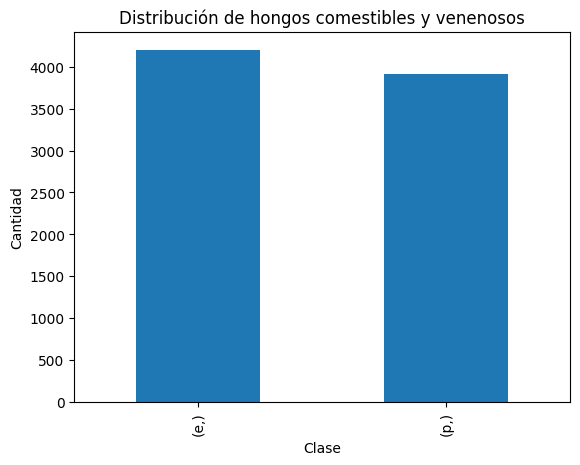

In [ ]:
# %% [markdown]
# ## 2. EDA básico

# Ver tamaño del dataset
print("Filas y columnas:", df.shape)

# Ver información general
print(df.info())

# Ver nombres de columnas
print("Columnas:")
print(df.columns)

# Ver valores faltantes
print("Valores faltantes:")
print(df.isnull().sum())

# Ver estadísticas descriptivas de variables categóricas
display(df.describe(include="object"))

# Ver distribución de la variable objetivo
print("Distribución de la variable objetivo:")
print(y.value_counts())

# Gráfico de la variable objetivo
y.value_counts().plot(kind="bar")
plt.title("Distribución de hongos comestibles y venenosos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# %% [markdown]
# ## 3. Definir variable objetivo, X e y

# Ver nombre de la variable objetivo
print("Variable objetivo:")
print(y.columns)

# Convertir y a una sola columna
y = y.iloc[:, 0]

# Codificar y porque es categórica
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Ver equivalencia de clases
print("Clases originales:", label_encoder.classes_)
print("Clases codificadas:", np.unique(y_encoded))

# Mantener X como variables explicativas
X_modelo = X.copy()

# Ver primeras filas de X
X_modelo.head()

Variable objetivo:
Index(['poisonous'], dtype='object')
Clases originales: ['e' 'p']
Clases codificadas: [0 1]


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# %% [markdown]
# ## 4. Eliminar columnas no necesarias

# En este dataset todas las columnas son características del hongo
# Por eso no eliminamos columnas al inicio

# Si quieres eliminar alguna columna después, puedes agregarla aquí
columnas_eliminar = []

X_modelo = X_modelo.drop(columnas_eliminar, axis=1)

# Ver columnas finales
print("Columnas finales:")
print(X_modelo.columns)

Columnas finales:
Index(['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')


In [ ]:
# %% [markdown]
# ## 5. Dividir en Training y Testing

# Dividir antes de imputar y codificar para evitar fuga de información
X_train, X_test, y_train, y_test = train_test_split(
    X_modelo,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (5686, 22)
Tamaño X_test: (2438, 22)


In [ ]:
# %% [markdown]
# ## 6. Imputación, OneHotEncoder y escalamiento

# Imputar datos categóricos con el valor más frecuente
imputador = SimpleImputer(strategy="most_frequent")

X_train_imp = imputador.fit_transform(X_train)
X_test_imp = imputador.transform(X_test)

# Convertir variables categóricas en variables dummy con OneHotEncoder
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_final = onehot.fit_transform(X_train_imp)
X_test_final = onehot.transform(X_test_imp)

# Obtener nombres de las columnas creadas por OneHotEncoder
nombres_variables = onehot.get_feature_names_out(X_modelo.columns)

# En Naïve Bayes con variables binarias no es necesario escalar
# BernoulliNB trabaja bien con columnas 0/1

print("Tamaño final X_train:", X_train_final.shape)
print("Tamaño final X_test:", X_test_final.shape)

print("Primeras variables creadas:")
print(nombres_variables[:20])

Tamaño final X_train: (5686, 116)
Tamaño final X_test: (2438, 116)
Primeras variables creadas:
['cap-shape_b' 'cap-shape_c' 'cap-shape_f' 'cap-shape_k' 'cap-shape_s'
 'cap-shape_x' 'cap-surface_f' 'cap-surface_g' 'cap-surface_s'
 'cap-surface_y' 'cap-color_b' 'cap-color_c' 'cap-color_e' 'cap-color_g'
 'cap-color_n' 'cap-color_p' 'cap-color_r' 'cap-color_u' 'cap-color_w'
 'cap-color_y']


In [ ]:
# %% [markdown]
# ## 7. Crear el modelo Naïve Bayes, entrenar y predecir

# Crear modelo Naïve Bayes para variables binarias
modelo_nb = BernoulliNB()

# Entrenar modelo
modelo_nb.fit(X_train_final, y_train)

# Predecir categorías
y_pred = modelo_nb.predict(X_test_final)

# Predecir probabilidades para la curva ROC
y_prob = modelo_nb.predict_proba(X_test_final)[:, 1]

Accuracy: 0.9397046759639048
Matriz de Confusión:
[[1246   17]
 [ 130 1045]]
              precision    recall  f1-score   support

           e       0.91      0.99      0.94      1263
           p       0.98      0.89      0.93      1175

    accuracy                           0.94      2438
   macro avg       0.94      0.94      0.94      2438
weighted avg       0.94      0.94      0.94      2438

AUC: 0.9961867219218005


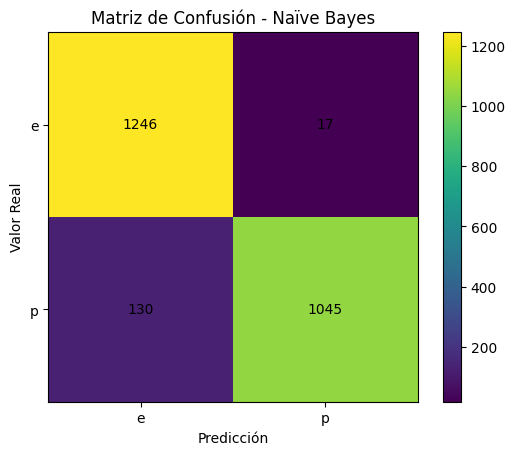

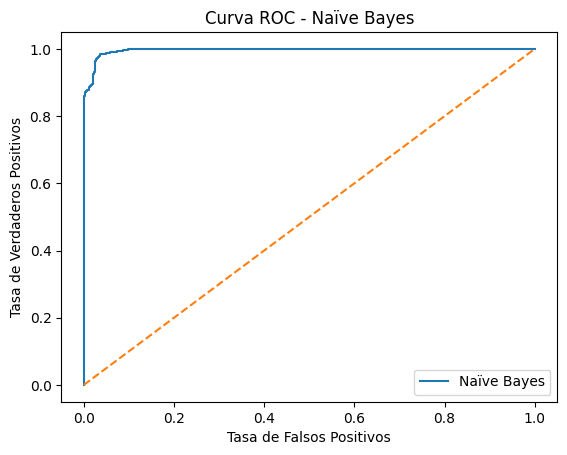

In [ ]:
# %% [markdown]
# ## 8. Métricas del modelo

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(matriz)

# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

# Gráfico de matriz de confusión
plt.imshow(matriz)
plt.title("Matriz de Confusión - Naïve Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.xticks([0, 1], label_encoder.classes_)
plt.yticks([0, 1], label_encoder.classes_)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Naïve Bayes")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC - Naïve Bayes")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.show()

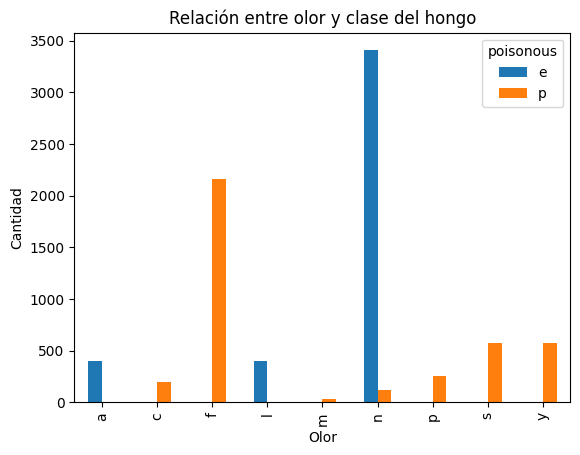

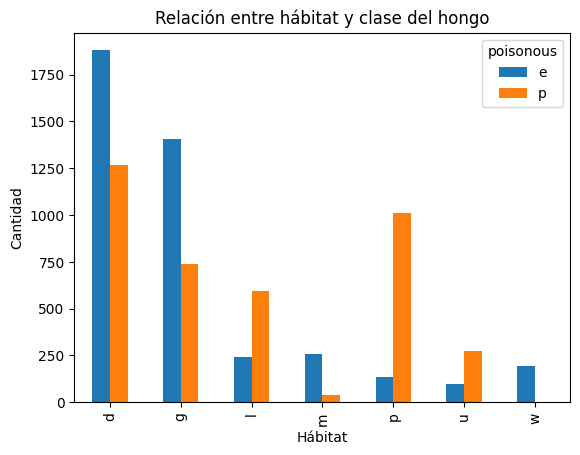

,Variable,Importancia
27,odor_n,0.015505
24,odor_f,0.014684
23,odor_c,0.011649
90,ring-type_f,0.003774
95,spore-print-color_h,0.003692
75,stalk-color-below-ring_g,0.002543
36,gill-size_n,0.001969
35,gill-size_b,0.001969
66,stalk-color-above-ring_g,0.001887
59,stalk-surface-below-ring_f,0.001887


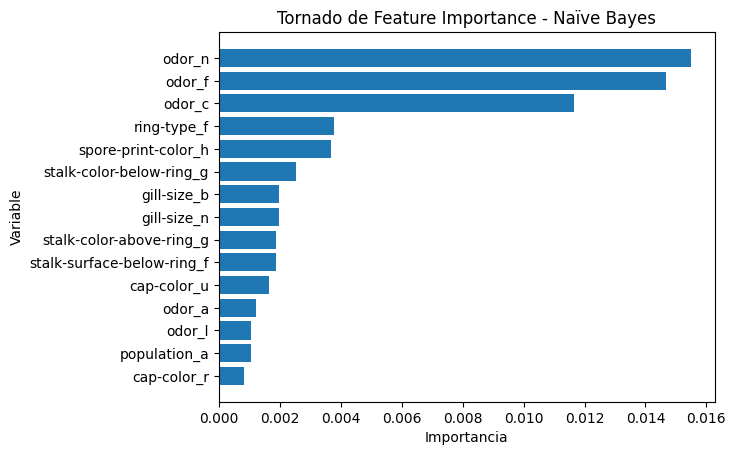

In [ ]:
# %% [markdown]
# ## 9. Visualizar datos y Tornado de Feature Importance

# Visualizar una variable importante contra la clase
pd.crosstab(df["odor"], df[y.name]).plot(kind="bar")
plt.title("Relación entre olor y clase del hongo")
plt.xlabel("Olor")
plt.ylabel("Cantidad")
plt.show()

# Visualizar otra variable contra la clase
pd.crosstab(df["habitat"], df[y.name]).plot(kind="bar")
plt.title("Relación entre hábitat y clase del hongo")
plt.xlabel("Hábitat")
plt.ylabel("Cantidad")
plt.show()

# Calcular importancia de variables por permutación
# Naïve Bayes no tiene importancia directa, por eso usamos permutation importance
importancia = permutation_importance(
    modelo_nb,
    X_test_final,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

# Crear tabla de importancia
df_importancia = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": importancia.importances_mean
})

# Ordenar de mayor a menor importancia
df_importancia = df_importancia.sort_values("Importancia", ascending=False)

# Mostrar principales variables
display(df_importancia.head(15))

# Gráfico tornado
top_importancia = df_importancia.head(15).sort_values("Importancia")

plt.barh(top_importancia["Variable"], top_importancia["Importancia"])
plt.title("Tornado de Feature Importance - Naïve Bayes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [ ]:
# %% [markdown]
# ## 10. Interfaz de predicción simple

# Tomar un ejemplo del dataset para crear una nueva predicción
# Puedes cambiar estos valores manualmente para probar otro hongo

hongo_nuevo = pd.DataFrame({
    "cap-shape": ["x"],
    "cap-surface": ["s"],
    "cap-color": ["n"],
    "bruises": ["t"],
    "odor": ["p"],
    "gill-attachment": ["f"],
    "gill-spacing": ["c"],
    "gill-size": ["n"],
    "gill-color": ["k"],
    "stalk-shape": ["e"],
    "stalk-root": ["e"],
    "stalk-surface-above-ring": ["s"],
    "stalk-surface-below-ring": ["s"],
    "stalk-color-above-ring": ["w"],
    "stalk-color-below-ring": ["w"],
    "veil-type": ["p"],
    "veil-color": ["w"],
    "ring-number": ["o"],
    "ring-type": ["p"],
    "spore-print-color": ["k"],
    "population": ["s"],
    "habitat": ["u"]
})

# Aplicar los mismos pasos usados en el entrenamiento
hongo_imp = imputador.transform(hongo_nuevo)
hongo_final = onehot.transform(hongo_imp)

# Predecir clase
prediccion = modelo_nb.predict(hongo_final)

# Predecir probabilidades
probabilidad = modelo_nb.predict_proba(hongo_final)

# Convertir predicción numérica a texto
resultado = label_encoder.inverse_transform(prediccion)

print("Predicción del hongo:", resultado[0])
print("Probabilidades por clase:")

for clase, prob in zip(label_encoder.classes_, probabilidad[0]):
    print(clase, ":", prob)

print("Conclusión:")
print("Naïve Bayes estima la clase del hongo usando probabilidades.")
print("Cada característica del hongo aporta evidencia para clasificarlo.")
print("Este dataset es útil para enseñar Naïve Bayes porque casi todas las variables son categóricas.")
print("Después de OneHotEncoder, BernoulliNB trabaja con variables binarias 0/1.")

Predicción del hongo: e
Probabilidades por clase:
e : 0.9918595656317767
p : 0.008140434368219844
Conclusión:
Naïve Bayes estima la clase del hongo usando probabilidades.
Cada característica del hongo aporta evidencia para clasificarlo.
Este dataset es útil para enseñar Naïve Bayes porque casi todas las variables son categóricas.
Después de OneHotEncoder, BernoulliNB trabaja con variables binarias 0/1.
